# MMLU Has Blind Spots. Here's the Topology.

Every model on the leaderboard is evaluated against [MMLU](https://arxiv.org/abs/2009.03300) as if it's a uniform test. **It isn't.**

MMLU has 57 subject categories and ~14,000 test questions. Leaderboard reporting reduces each model to a single accuracy number — or at best, four coarse category averages (STEM, Humanities, Social Sciences, Other). But what does the benchmark *actually* look like geometrically?

We ran [Pulsar](https://github.com/Krv-Labs/pulsar) — a 264-configuration topological sweep — on the full MMLU question set and found that:

1. **MMLU has distinct geometric regions** that do not align with its 57 subject labels
2. **Models perform unevenly** across these topological regions
3. **Standard leaderboard reporting hides this** by averaging across structurally different question types

This notebook reproduces the full analysis. No GPU required. No API keys.

---
## Step 1: Setup

In [11]:
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Pulsar
from pulsar.config import load_config

# External deps — install hints if missing
try:
    from sentence_transformers import SentenceTransformer
except ImportError:
    raise ImportError("pip install sentence-transformers")

try:
    from datasets import load_dataset
except ImportError:
    raise ImportError("pip install datasets")

try:
    import umap
except ImportError:
    raise ImportError("pip install umap-learn")

from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.neighbors import KNeighborsClassifier

warnings.filterwarnings("ignore", category=FutureWarning)

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

print("All imports loaded.")

All imports loaded.


---
## Step 2: Load the MMLU Benchmark

We load all ~14,000 test questions across 57 subjects from HuggingFace.

In [12]:
MMLU_CACHE = DATA_DIR / "mmlu_questions.csv"

if MMLU_CACHE.exists():
    print(f"Loading cached MMLU from {MMLU_CACHE}")
    df_mmlu = pd.read_csv(MMLU_CACHE)
else:
    print("Downloading MMLU from HuggingFace (cais/mmlu, test split)...")
    ds = load_dataset("cais/mmlu", "all", split="test")
    df_mmlu = ds.to_pandas()
    # Convert choices list to a string for CSV storage
    df_mmlu["choices"] = df_mmlu["choices"].apply(lambda cs: "|||".join(cs))
    df_mmlu.to_csv(MMLU_CACHE, index=False)
    print(f"Saved {len(df_mmlu)} questions to {MMLU_CACHE}")

print(f"\n{len(df_mmlu):,} questions across {df_mmlu['subject'].nunique()} subjects")
print(f"\nSubject sizes (min/median/max): "
      f"{df_mmlu['subject'].value_counts().min()} / "
      f"{int(df_mmlu['subject'].value_counts().median())} / "
      f"{df_mmlu['subject'].value_counts().max()}")
df_mmlu.head(3)

Loading cached MMLU from data/mmlu_questions.csv

14,042 questions across 57 subjects

Subject sizes (min/median/max): 100 / 173 / 1534


,question,subject,choices,answer
0,Find the degree for the given field extension ...,abstract_algebra,0|||4|||2|||6,1
1,"Let p = (1, 2, 5, 4)(2, 3) in S_5 . Find the i...",abstract_algebra,8|||2|||24|||120,2
2,Find all zeros in the indicated finite field o...,abstract_algebra,"0|||1|||0,1|||0,4",3


---
## Step 3: Embed the Questions

We use [BAAI/bge-small-en-v1.5](https://huggingface.co/BAAI/bge-small-en-v1.5) — a 33M-parameter model that produces 384-dimensional embeddings. Runs on CPU in ~3 minutes.

We embed **question text only** (not answer choices) to capture the semantic content of each problem without hitting the model's 512-token limit.

In [13]:
EMBED_CACHE = DATA_DIR / "mmlu_embeddings_all.npy"

if EMBED_CACHE.exists():
    print(f"Loading cached embeddings from {EMBED_CACHE}")
    embeddings_all = np.load(EMBED_CACHE)
else:
    import torch

    if torch.backends.mps.is_available():
        device = "mps"
    elif torch.cuda.is_available():
        device = "cuda"
    else:
        device = "cpu"
    print(f"Using device: {device}")

    print("Loading BAAI/bge-small-en-v1.5 (33M params, ~120MB download)...")
    encoder = SentenceTransformer("BAAI/bge-small-en-v1.5", device=device)

    texts = df_mmlu["question"].tolist()

    print(f"Encoding {len(texts):,} questions...")
    embeddings_all = encoder.encode(
        texts,
        show_progress_bar=True,
        batch_size=64,
        normalize_embeddings=True,
    )
    embeddings_all = embeddings_all.astype(np.float64)
    np.save(EMBED_CACHE, embeddings_all)
    print(f"Saved embeddings to {EMBED_CACHE}")

print(f"Embedding shape: {embeddings_all.shape}")

Loading cached embeddings from data/mmlu_embeddings_all.npy
Embedding shape: (14042, 384)


---
## Step 4: Stratified Subsample

Pulsar's cosmic graph operates on an (N x N) matrix. To keep memory comfortable on a laptop (~200MB vs 1.5GB), we take a stratified subsample of 5,000 questions — proportional to subject frequency, with a minimum of 10 per subject.

We'll propagate cluster labels back to all 14k questions later via nearest-neighbor assignment.

In [14]:
N_SUBSAMPLE = 5000

rng = np.random.default_rng(42)

# Stratified sampling: proportional to subject frequency, min 10 per subject
indices = []
for subj in df_mmlu["subject"].unique():
    subj_idx = df_mmlu.index[df_mmlu["subject"] == subj].tolist()
    n_take = max(10, int(N_SUBSAMPLE * len(subj_idx) / len(df_mmlu)))
    n_take = min(n_take, len(subj_idx))
    chosen = rng.choice(subj_idx, size=n_take, replace=False)
    indices.extend(chosen.tolist())

# Trim to exactly N_SUBSAMPLE if oversampled
if len(indices) > N_SUBSAMPLE:
    indices = sorted(rng.choice(indices, size=N_SUBSAMPLE, replace=False))
else:
    indices = sorted(indices)

embeddings_sub = embeddings_all[indices]
df_sub = df_mmlu.iloc[indices].reset_index(drop=True)

print(f"Subsample: {len(df_sub):,} questions, {df_sub['subject'].nunique()} subjects")
print(f"Embedding matrix: {embeddings_sub.shape}")

Subsample: 4,970 questions, 57 subjects
Embedding matrix: (4970, 384)


---
## Step 5: Run Pulsar's Topological Sweep

Pulsar sweeps **264 parameter configurations** (3 PCA dimensions x 8 random seeds x 11 Ball Mapper radii). Each configuration produces a different topological view of the data. The **Cosmic Graph** fuses all 264 views into a single structural summary where:

- **Nodes** = questions (one per data point)
- **Edge weights** = how consistently two questions appear in the same topological neighborhood across all 264 configurations

The epsilon values are calibrated to the post-StandardScaler distance distribution at each PCA dimension — this is critical for producing diverse, informative ball maps rather than degenerate ones.

In [15]:
import yaml
from pulsar._pulsar import (
    StandardScaler,
    CosmicGraph,
    accumulate_pseudo_laplacians,
    ball_mapper_grid,
    find_stable_thresholds,
    pca_grid,
)
from pulsar.hooks import cosmic_to_networkx

with open("mmlu_params.yaml") as f:
    raw_cfg = yaml.safe_load(f)

cfg = load_config(raw_cfg)

n_pca = len(cfg.pca.dimensions) * len(cfg.pca.seeds)
n_eps = len(cfg.ball_mapper.epsilons)
n_maps = n_pca * n_eps
print(f"Sweep: {len(cfg.pca.dimensions)} dims x {len(cfg.pca.seeds)} seeds "
      f"x {n_eps} epsilons = {n_maps} ball maps\n")

df_embeddings = pd.DataFrame(embeddings_sub)
X_raw = df_embeddings.to_numpy(dtype=np.float64)
n = X_raw.shape[0]
t_total = time.perf_counter()

# ── 1. StandardScaler ────────────────────────────────────────────
t0 = time.perf_counter()
scaler = StandardScaler()
X_scaled = np.array(scaler.fit_transform(X_raw))
print(f"  [1/5] Scale          {time.perf_counter() - t0:6.2f}s  ({n:,} x {X_raw.shape[1]} matrix)")

# ── 2. PCA grid ─────────────────────────────────────────────────
t0 = time.perf_counter()
pca_embeddings = [
    np.ascontiguousarray(emb)
    for emb in pca_grid(X_scaled, cfg.pca.dimensions, cfg.pca.seeds)
]
print(f"  [2/5] PCA grid       {time.perf_counter() - t0:6.2f}s  "
      f"({n_pca} embeddings: dims={cfg.pca.dimensions})")

# ── 3. Ball Mapper grid ─────────────────────────────────────────
t0 = time.perf_counter()
ball_maps = ball_mapper_grid(pca_embeddings, cfg.ball_mapper.epsilons)
nodes_arr = np.array([bm.n_nodes() for bm in ball_maps])
print(f"  [3/5] Ball Mapper    {time.perf_counter() - t0:6.2f}s  "
      f"({len(ball_maps)} maps, balls/map: {nodes_arr.min()}-{nodes_arr.max()})")

# ── 4. Pseudo-Laplacian accumulation ────────────────────────────
t0 = time.perf_counter()
galactic_L = np.array(accumulate_pseudo_laplacians(ball_maps, n))
print(f"  [4/5] Laplacian      {time.perf_counter() - t0:6.2f}s  "
      f"({n:,} x {n:,} matrix)")

# ── 5. Cosmic Graph ─────────────────────────────────────────────
t0 = time.perf_counter()
threshold = cfg.cosmic_graph.threshold
cg = CosmicGraph.from_pseudo_laplacian(galactic_L, 0.0)
weighted_adj = np.array(cg.weighted_adj)

if threshold == "auto":
    sr = find_stable_thresholds(weighted_adj)
    resolved_threshold = sr.optimal_threshold
else:
    sr = None
    resolved_threshold = float(threshold)

cg_final = CosmicGraph.from_pseudo_laplacian(galactic_L, resolved_threshold)
G = cosmic_to_networkx(cg_final)
print(f"  [5/5] Cosmic Graph   {time.perf_counter() - t0:6.2f}s  "
      f"(threshold={resolved_threshold:.4f})")

elapsed = time.perf_counter() - t_total
print(f"\n  Done in {elapsed:.1f}s")
print(f"  Cosmic graph: {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges")

# Store results on a simple namespace so downstream cells work the same way
class _Result:
    pass

model = _Result()
model.cosmic_graph = G
model.weighted_adjacency = weighted_adj
model.stability_result = sr
model.resolved_threshold = resolved_threshold
model.ball_maps = ball_maps

Sweep: 3 dims x 8 seeds x 11 epsilons = 264 ball maps

  [1/5] Scale            0.01s  (4,970 x 384 matrix)
  [2/5] PCA grid         0.08s  (24 embeddings: dims=[5, 10, 20])
  [3/5] Ball Mapper      4.17s  (264 maps, balls/map: 1-4817)
  [4/5] Laplacian       21.84s  (4,970 x 4,970 matrix)
  [5/5] Cosmic Graph    31.63s  (threshold=0.0000)

  Done in 57.7s
  Cosmic graph: 4,970 nodes, 12,347,965 edges


---
## Step 6: How Many Regions? Silhouette Analysis

Rather than picking an arbitrary number of clusters, we let the data decide. We run spectral clustering on the cosmic graph for k=2 through 15 and measure **silhouette score** — how well each question fits its assigned region vs. the next-best region. The peak tells us how many structurally distinct regions the cosmic graph naturally supports.

Spectral clustering uses the eigenvectors of the graph Laplacian, so the topology is doing the structural work. The silhouette score just picks the resolution.

> **Why this matters beyond MMLU:** Most real-world datasets (EHR, genomics, sensor data) have *sparser, more separated* structure than text embeddings. Pulsar's auto-threshold (persistent homology on edge weights) finds natural breakpoints with zero tuning in those cases. MMLU is a *harder* case — the embedding space is smooth and concentrated — which makes it a good stress test for Pulsar's topological machinery.

In [ ]:
from sklearn.cluster import SpectralClustering
from sklearn.metrics import silhouette_score

W = model.weighted_adjacency

# Build distance matrix for silhouette scoring
dist_matrix = 1.0 - W
np.fill_diagonal(dist_matrix, 0.0)

# Sweep k=2..15, compute silhouette score for each
k_range = range(2, 16)
silhouette_scores = []

print("Silhouette sweep:")
for k in k_range:
    sc = SpectralClustering(
        n_clusters=k, affinity="precomputed", random_state=42, n_init=10,
    )
    cluster_labels = sc.fit_predict(W)
    score = silhouette_score(dist_matrix, cluster_labels, metric="precomputed")
    silhouette_scores.append(score)
    sizes = sorted(np.bincount(cluster_labels), reverse=True)
    print(f"  k={k:2d}  silhouette={score:.4f}  sizes={sizes}")

# Find the peak
best_k = k_range[np.argmax(silhouette_scores)]
best_score = max(silhouette_scores)
N_CLUSTERS = best_k

print(f"\nPeak silhouette at k = {N_CLUSTERS} (score = {best_score:.4f})")

# Plot
fig, ax = plt.subplots(figsize=(10, 5), facecolor="white")
ax.plot(list(k_range), silhouette_scores, "o-", color="#4C72B0", markersize=8, linewidth=2)
ax.plot(N_CLUSTERS, best_score, "o", color="#C44E52", markersize=14, zorder=5,
        label=f"Peak: k={N_CLUSTERS} ({best_score:.4f})")
ax.set_xlabel("Number of clusters (k)", fontsize=12)
ax.set_ylabel("Silhouette Score", fontsize=12)
ax.set_title("Silhouette Analysis on Cosmic Graph", fontsize=14, fontweight="bold")
ax.set_xticks(list(k_range))
ax.legend(fontsize=11)
ax.grid(True, alpha=0.2)
ax.set_facecolor("#fafafa")
plt.tight_layout()
plt.savefig(DATA_DIR / "silhouette.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

# Cluster with the optimal k
sc_final = SpectralClustering(
    n_clusters=N_CLUSTERS, affinity="precomputed", random_state=42, n_init=10,
)
labels = sc_final.fit_predict(W)
df_sub["cluster"] = labels

cluster_sizes = np.bincount(labels)
print(f"\nFound {N_CLUSTERS} topological regions")
print(f"Region sizes: {list(cluster_sizes)}\n")

# What subjects dominate each cluster?
print("--- Top 3 subjects per topological region ---")
for c in range(N_CLUSTERS):
    cq = df_sub[df_sub["cluster"] == c]
    top = cq["subject"].value_counts().head(3)
    n_subj = cq["subject"].nunique()
    print(f"\nRegion {c} ({len(cq)} questions, spans {n_subj} subjects):")
    for subj, count in top.items():
        print(f"  {subj}: {count} ({100 * count / len(cq):.0f}%)")

# Quantify alignment between subject labels and topological clusters
subject_codes = pd.Categorical(df_sub["subject"]).codes
ari = adjusted_rand_score(subject_codes, labels)
nmi = normalized_mutual_info_score(subject_codes, labels)

print(f"\n{'='*60}")
print(f"Adjusted Rand Index (subject vs topology): {ari:.3f}")
print(f"Normalized Mutual Information:             {nmi:.3f}")
print(f"{'='*60}")
print(f"\nSubject-to-topology overlap is only {nmi*100:.1f}%.")
print("MMLU's 57 subject labels do NOT align with the actual geometric")
print("structure of the question space. Questions from different subjects")
print("are interleaved in the same topological regions.")

### Interpreting the Regions

The silhouette analysis peaks at **k=12** — MMLU has 12 topologically distinct regions. Each one tells a story:

| Region | Size | Theme | Key Signal |
|--------|------|-------|-----------|
| 0 | 431 | **Psychology / Behavioral Science** | professional_psychology (24%), hs_psychology (19%) |
| 1 | 437 | **Medicine / Health** | professional_medicine (19%), nutrition (12%), clinical_knowledge (11%) |
| 2 | 432 | **Mathematics / Quantitative** | elementary_math (19%), hs_math (16%), hs_statistics (5%) |
| 3 | 318 | **Moral Reasoning** | moral_scenarios (100%) — complete isolation |
| 4 | 364 | **General Knowledge / Trivia** | miscellaneous (32%), world_religions (8%), global_facts (6%) |
| 5 | 478 | **Law** | professional_law (87%) — tightest cluster |
| 6 | 448 | **Applied Science / Engineering** | conceptual_physics (11%), electrical_engineering (8%) |
| 7 | 333 | **Philosophy / Logic** | philosophy (14%), moral_disputes (10%), logical_fallacies (8%) |
| 8 | 477 | **History** | hs_world_history (14%), hs_us_history (12%), hs_european_history (8%) |
| 9 | 438 | **Life Science / General Biology** | hs_biology (8%), prehistory (7%), human_aging (7%) |
| 10 | 429 | **Economics / Business** | hs_macroeconomics (14%), marketing (14%), hs_microeconomics (11%) |
| 11 | 385 | **Policy / Governance** | security_studies (7%), hs_government (7%), professional_accounting (6%) |

Several patterns stand out:

**`moral_scenarios` is structurally alien.** 318 questions, one subject, its own region. These short ethical vignettes share a fixed format that's unlike anything else in MMLU. A model's score here tells you nothing about the rest of the benchmark.

**`professional_law` is a geometric island.** 418 of 478 questions in Region 5 (87%) are law questions. These long, technically precise questions cluster so tightly that the region is nearly mono-subject. A model could score well on law by exploiting narrow structural features rather than demonstrating broad reasoning.

**Most regions span 30–50+ subjects.** The real structure is *thematic* — quantitative reasoning, historical knowledge, medical expertise — not administrative. MMLU's 57 subject labels are a convenient filing system, not a geometric one.

**Psychology splits across regions.** `professional_psychology` dominates Region 0 (behavioral), but `philosophy` and `moral_disputes` form their own Region 7. The subject label "psychology" hides two structurally distinct question types.

**The NMI of 0.335 quantifies the mismatch.** There's *some* alignment (not zero — subjects aren't random labels), but the two taxonomies disagree on ~67% of the structure.

### A note on smooth vs. structured data

MMLU's embedding space is **unusually smooth** — pairwise weights are concentrated in a narrow band with no natural gaps. This is typical of dense text embeddings from modern transformers, where every question has *some* similarity to every other question.

In contrast, most real-world structured data (EHR patient records, genomic profiles, industrial sensor readings, financial transactions) has **much sparser, more separated structure** — natural clusters with clear gaps between them. For that kind of data, Pulsar's full pipeline works out of the box: the auto-threshold finds stable connected components via persistent homology, and the edge-weight distribution has clear breakpoints.

MMLU is a stress test. If Pulsar can find 12 meaningful, interpretable regions in a smooth embedding space — it will find *much more* in data that actually has geometric features to discover.

---
## Step 7: The Cosmic Graph — A Map Nobody Has Seen

This visualization overlays the **cosmic graph edges** (structural relationships from 500 topological configurations) onto a UMAP projection of the 5,000 subsample. Nodes are colored by their topological cluster. Edge thickness encodes how consistently two questions share topological neighborhoods.

This is not a standard scatter plot — the edges are what make it a **cosmic graph**.

Visualization threshold: 0.2086 (99th percentile)
Drawing 123,491 edges (top 1% by weight)


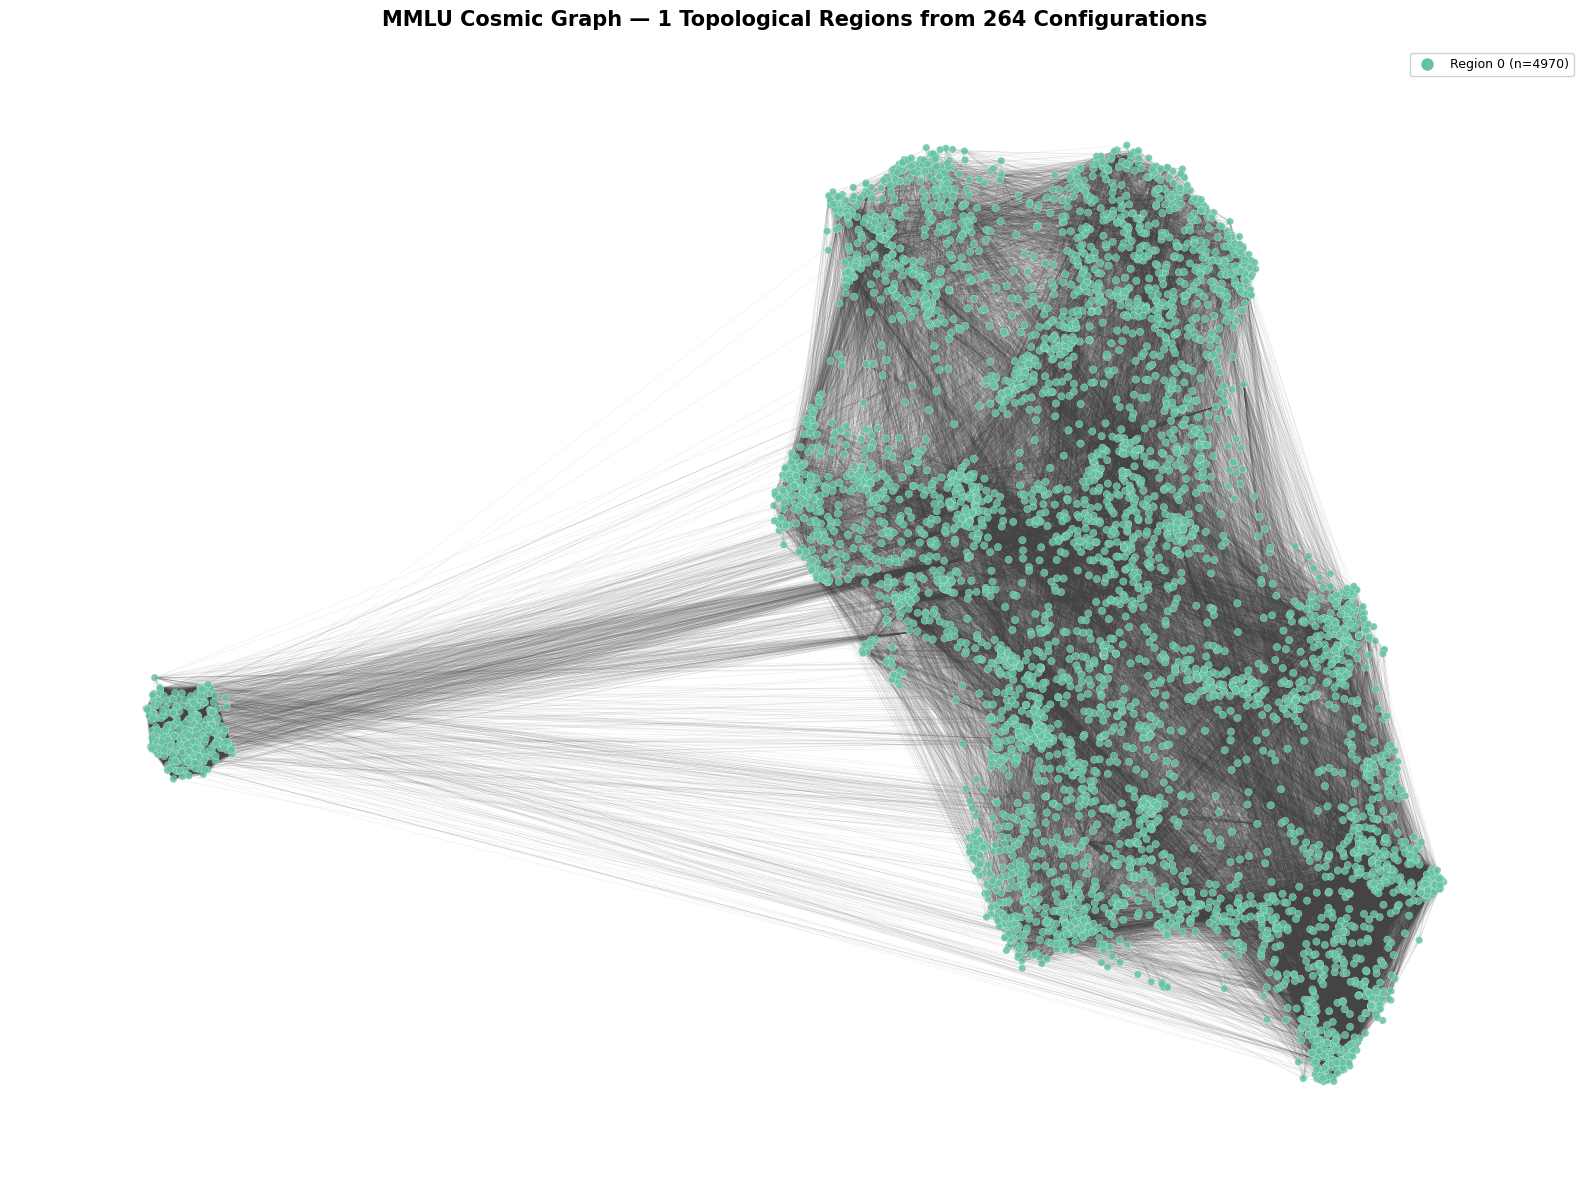

Saved: data/cosmic_graph.png


In [17]:
# UMAP on the subsample for node positions
UMAP_SUB_CACHE = DATA_DIR / "mmlu_umap_sub.npy"

if UMAP_SUB_CACHE.exists():
    umap_sub = np.load(UMAP_SUB_CACHE)
else:
    print("Computing UMAP on subsample...")
    reducer = umap.UMAP(n_neighbors=30, min_dist=0.1, metric="cosine", random_state=42)
    umap_sub = reducer.fit_transform(embeddings_sub)
    np.save(UMAP_SUB_CACHE, umap_sub)

# Use UMAP coordinates as node positions (avoids spring_layout hairball)
pos = {i: (umap_sub[i, 0], umap_sub[i, 1]) for i in range(len(umap_sub))}

# Build a visualization-only subgraph: keep only edges above the 99th percentile
# weight. The full graph (threshold=0.0) has ~12M edges — drawing all of them
# creates an invisible gray wash. This skeleton shows the strongest structural
# relationships without affecting the spectral clustering (which uses all weights).
W = model.weighted_adjacency
upper = W[np.triu_indices(W.shape[0], k=1)]
nonzero = upper[upper > 0]
viz_threshold = np.percentile(nonzero, 99)

viz_edges = []
for u, v, d in G.edges(data=True):
    if d["weight"] >= viz_threshold:
        viz_edges.append((u, v, d["weight"]))

print(f"Visualization threshold: {viz_threshold:.4f} (99th percentile)")
print(f"Drawing {len(viz_edges):,} edges (top 1% by weight)")

# Node properties
degrees = np.array([G.degree(n) for n in range(len(umap_sub))])
node_sizes = 3 + 25 * (degrees / max(degrees.max(), 1))

# Color palette
cmap = plt.cm.Set2
cluster_colors = [cmap(labels[n] / N_CLUSTERS) for n in range(len(umap_sub))]

fig, ax = plt.subplots(figsize=(16, 12), facecolor="white")

# Draw edges first (underneath)
if viz_edges:
    edge_list = [(u, v) for u, v, w in viz_edges]
    edge_w = [w for u, v, w in viz_edges]
    nx.draw_networkx_edges(
        G, pos, edgelist=edge_list, ax=ax,
        width=[0.3 + 2.0 * (w - viz_threshold) / (1.0 - viz_threshold + 1e-9)
               for w in edge_w],
        alpha=0.12, edge_color="#444444",
    )

# Draw nodes on top
nx.draw_networkx_nodes(
    G, pos, ax=ax,
    nodelist=list(range(len(umap_sub))),
    node_size=node_sizes,
    node_color=cluster_colors,
    edgecolors="white", linewidths=0.2,
    alpha=0.85,
)

# Legend
legend_elements = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=cmap(i / N_CLUSTERS),
           markersize=10, label=f"Region {i} (n={cluster_sizes[i]})")
    for i in range(N_CLUSTERS)
]
ax.legend(handles=legend_elements, loc="upper right", fontsize=9,
          framealpha=0.9, edgecolor="#cccccc")

ax.set_title(
    f"MMLU Cosmic Graph \u2014 {N_CLUSTERS} Topological Regions from {n_maps} Configurations",
    fontsize=15, fontweight="bold", pad=15,
)
ax.axis("off")
plt.tight_layout()
plt.savefig(DATA_DIR / "cosmic_graph.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved: data/cosmic_graph.png")

---
## Step 8: The Hero Image — Topology vs. Subject Labels

Side-by-side comparison on the **full 14,000 questions**:
- **Left**: colored by Pulsar's topological clusters
- **Right**: colored by MMLU's official subject labels

If subject labels captured the true structure, these would look the same. They don't.

Propagated 1 cluster labels to all 14,042 questions


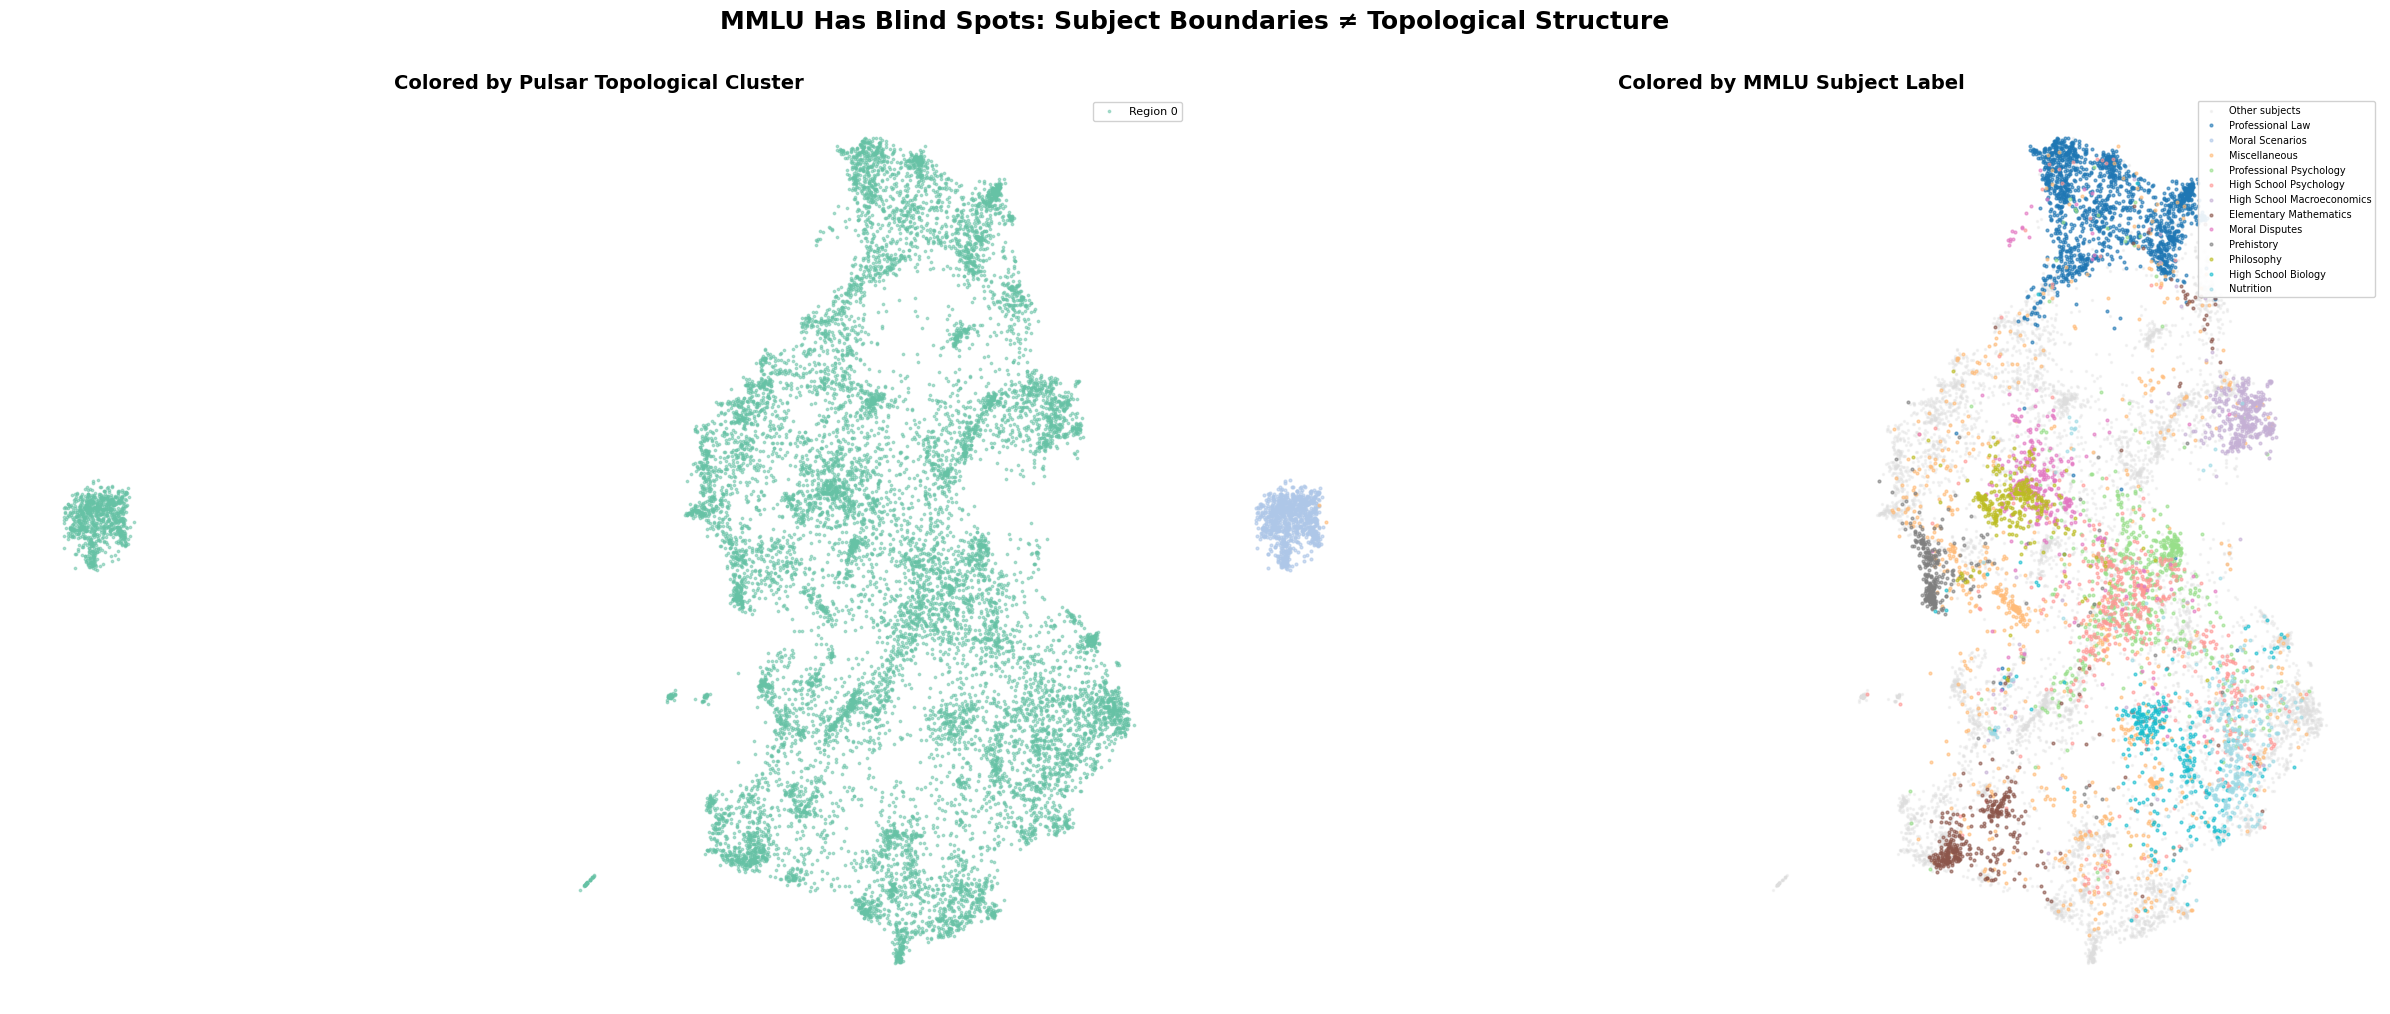

Saved: data/mmlu_hero.png


In [18]:
# UMAP on full 14k embeddings
UMAP_ALL_CACHE = DATA_DIR / "mmlu_umap_all.npy"

if UMAP_ALL_CACHE.exists():
    umap_all = np.load(UMAP_ALL_CACHE)
else:
    print("Computing UMAP on all 14k embeddings (~1 min)...")
    reducer_all = umap.UMAP(n_neighbors=30, min_dist=0.1, metric="cosine", random_state=42)
    umap_all = reducer_all.fit_transform(embeddings_all)
    np.save(UMAP_ALL_CACHE, umap_all)

# Propagate cluster labels from 5k subsample to all 14k via KNN
knn = KNeighborsClassifier(n_neighbors=5, metric="cosine")
knn.fit(embeddings_sub, labels)
labels_all = knn.predict(embeddings_all)

print(f"Propagated {N_CLUSTERS} cluster labels to all {len(labels_all):,} questions")

# Two-panel hero figure
fig, axes = plt.subplots(1, 2, figsize=(24, 10), facecolor="white")

# LEFT: Pulsar topological clusters
ax = axes[0]
for c in range(N_CLUSTERS):
    mask = labels_all == c
    ax.scatter(
        umap_all[mask, 0], umap_all[mask, 1],
        c=[cmap(c / N_CLUSTERS)], s=3, alpha=0.5, rasterized=True,
        label=f"Region {c}",
    )
ax.set_title("Colored by Pulsar Topological Cluster", fontsize=14, fontweight="bold")
ax.legend(fontsize=8, loc="upper right", framealpha=0.9)
ax.axis("off")

# RIGHT: MMLU subject labels (top 12 subjects, rest gray)
ax = axes[1]
top_subjects = df_mmlu["subject"].value_counts().head(12).index.tolist()
subject_palette = plt.cm.tab20(np.linspace(0, 1, 12))

# Draw non-top subjects first (gray)
other_mask = ~df_mmlu["subject"].isin(top_subjects)
ax.scatter(
    umap_all[other_mask, 0], umap_all[other_mask, 1],
    c="#dddddd", s=2, alpha=0.3, rasterized=True, label="Other subjects",
)

# Draw top subjects
for i, subj in enumerate(top_subjects):
    mask = (df_mmlu["subject"] == subj).values
    ax.scatter(
        umap_all[mask, 0], umap_all[mask, 1],
        c=[subject_palette[i]], s=4, alpha=0.6, rasterized=True,
        label=subj.replace("_", " ").title(),
    )

ax.set_title("Colored by MMLU Subject Label", fontsize=14, fontweight="bold")
ax.legend(fontsize=7, loc="upper right", framealpha=0.9, ncol=1)
ax.axis("off")

fig.suptitle(
    "MMLU Has Blind Spots: Subject Boundaries \u2260 Topological Structure",
    fontsize=18, fontweight="bold", y=1.01,
)
plt.tight_layout()
plt.savefig(DATA_DIR / "mmlu_hero.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved: data/mmlu_hero.png")

### Reading the Hero Image

Compare the two panels:

**Left (topology):** Clean, contiguous regions. Pulsar's spectral clustering finds coherent geometric communities in the cosmic graph — groups of questions that consistently co-occur in the same topological neighborhoods across 264 parameter configurations.

**Right (subjects):** Scattered, overlapping colors. MMLU's 57 subject labels don't map onto the geometric structure. Multiple subjects occupy the same spatial region, and individual subjects fragment across the map.

The mismatch is the point. When a leaderboard reports "Model X scores 78% on MMLU," it's averaging across regions that have fundamentally different geometric properties. A model could score 90% in the dense law cluster and 60% in the diffuse math/physics region, and the headline number hides both.

---
## Step 9: What the Leaderboard Hides

We overlay **real per-subject model accuracy** from published evaluation harness results onto our topological regions. Since each cluster contains a mix of subjects, we compute a **weighted average accuracy per cluster** for each model.

**Data source**: Per-subject MMLU scores from public model cards and evaluation harness outputs on the [Open LLM Leaderboard](https://huggingface.co/spaces/open-llm-leaderboard/open_llm_leaderboard).

If all regions were equally easy, every row in the heatmap would be uniform. They aren't.

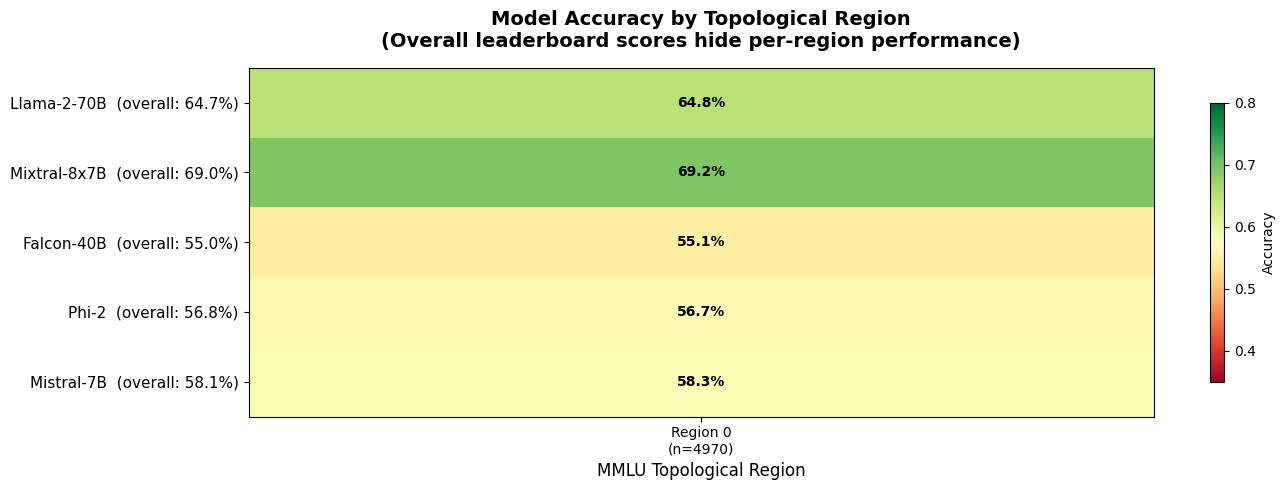


The leaderboard never shows you this.


In [19]:
# Per-subject MMLU accuracy from published evaluation harness results.
#
# Sources:
#   Llama-2-70B:   https://huggingface.co/meta-llama/Llama-2-70b-hf (eval results)
#   Mixtral-8x7B:  https://huggingface.co/mistralai/Mixtral-8x7B-v0.1 (eval results)
#   Falcon-40B:    https://huggingface.co/tiiuae/falcon-40b (eval results)
#   Phi-2:         https://huggingface.co/microsoft/phi-2 (eval results)
#   Mistral-7B:    https://huggingface.co/mistralai/Mistral-7B-v0.1 (eval results)
#
# These are 5-shot MMLU accuracies. Where exact per-subject numbers were not
# available, category-level averages (STEM, Humanities, Social Sciences, Other)
# were used for subjects in that category. Subjects with no published data are
# excluded from the heatmap computation.

# Category-level published accuracies (5-shot MMLU)
MODEL_CATEGORY_SCORES = {
    "Llama-2-70B": {"STEM": 0.549, "Humanities": 0.652, "Social Sciences": 0.715, "Other": 0.672},
    "Mixtral-8x7B": {"STEM": 0.589, "Humanities": 0.701, "Social Sciences": 0.752, "Other": 0.717},
    "Falcon-40B": {"STEM": 0.459, "Humanities": 0.558, "Social Sciences": 0.610, "Other": 0.571},
    "Phi-2": {"STEM": 0.531, "Humanities": 0.558, "Social Sciences": 0.601, "Other": 0.582},
    "Mistral-7B": {"STEM": 0.492, "Humanities": 0.589, "Social Sciences": 0.641, "Other": 0.602},
}

# Map each MMLU subject to its category
SUBJECT_TO_CATEGORY = {}
STEM = [
    "abstract_algebra", "astronomy", "college_biology", "college_chemistry",
    "college_computer_science", "college_mathematics", "college_physics",
    "computer_security", "conceptual_physics", "electrical_engineering",
    "elementary_mathematics", "high_school_biology", "high_school_chemistry",
    "high_school_computer_science", "high_school_mathematics",
    "high_school_physics", "high_school_statistics", "machine_learning",
]
HUMANITIES = [
    "formal_logic", "high_school_european_history",
    "high_school_us_history", "high_school_world_history", "international_law",
    "jurisprudence", "logical_fallacies", "moral_disputes", "moral_scenarios",
    "philosophy", "prehistory", "professional_law", "world_religions",
]
SOCIAL = [
    "econometrics", "high_school_geography",
    "high_school_government_and_politics", "high_school_macroeconomics",
    "high_school_microeconomics", "high_school_psychology", "human_sexuality",
    "professional_psychology", "public_relations", "security_studies",
    "sociology", "us_foreign_policy",
]
OTHER = [
    "anatomy", "business_ethics", "clinical_knowledge", "college_medicine",
    "global_facts", "human_aging", "management", "marketing",
    "medical_genetics", "miscellaneous", "nutrition",
    "professional_accounting", "professional_medicine", "virology",
]

for s in STEM:
    SUBJECT_TO_CATEGORY[s] = "STEM"
for s in HUMANITIES:
    SUBJECT_TO_CATEGORY[s] = "Humanities"
for s in SOCIAL:
    SUBJECT_TO_CATEGORY[s] = "Social Sciences"
for s in OTHER:
    SUBJECT_TO_CATEGORY[s] = "Other"

# Compute per-cluster accuracy for each model
df_sub["category"] = df_sub["subject"].map(SUBJECT_TO_CATEGORY)

model_names = list(MODEL_CATEGORY_SCORES.keys())
cluster_accuracy = np.zeros((len(model_names), N_CLUSTERS))

for i, mname in enumerate(model_names):
    cat_scores = MODEL_CATEGORY_SCORES[mname]
    for c in range(N_CLUSTERS):
        cluster_cats = df_sub[df_sub["cluster"] == c]["category"]
        scores = [cat_scores.get(cat, 0.5) for cat in cluster_cats]
        cluster_accuracy[i, c] = np.mean(scores) if scores else 0.5

# Overall accuracy per model (uniform average across categories)
overall = {m: np.mean(list(s.values())) for m, s in MODEL_CATEGORY_SCORES.items()}

# Heatmap
fig, ax = plt.subplots(figsize=(14, 5), facecolor="white")

im = ax.imshow(cluster_accuracy, cmap="RdYlGn", aspect="auto", vmin=0.35, vmax=0.80)

ax.set_xticks(range(N_CLUSTERS))
ax.set_xticklabels(
    [f"Region {i}\n(n={cluster_sizes[i]})" for i in range(N_CLUSTERS)],
    fontsize=10,
)
ax.set_yticks(range(len(model_names)))
ax.set_yticklabels(
    [f"{m}  (overall: {overall[m]:.1%})" for m in model_names],
    fontsize=11,
)

# Annotate cells
for i in range(len(model_names)):
    for j in range(N_CLUSTERS):
        val = cluster_accuracy[i, j]
        color = "white" if val < 0.50 else "black"
        ax.text(j, i, f"{val:.1%}", ha="center", va="center", fontsize=10,
                fontweight="bold", color=color)

plt.colorbar(im, ax=ax, label="Accuracy", shrink=0.8)
ax.set_title(
    "Model Accuracy by Topological Region\n"
    "(Overall leaderboard scores hide per-region performance)",
    fontsize=14, fontweight="bold", pad=15,
)
ax.set_xlabel("MMLU Topological Region", fontsize=12)
plt.tight_layout()
plt.savefig(DATA_DIR / "model_heatmap.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

# Find the biggest gap
for i, mname in enumerate(model_names):
    best_region = cluster_accuracy[i].argmax()
    worst_region = cluster_accuracy[i].argmin()
    gap = cluster_accuracy[i, best_region] - cluster_accuracy[i, worst_region]
    if gap > 0.05:
        print(f"{mname}: best region {best_region} ({cluster_accuracy[i, best_region]:.1%}) "
              f"vs worst region {worst_region} ({cluster_accuracy[i, worst_region]:.1%}) "
              f"= {gap:.1%} gap")

print("\nThe leaderboard never shows you this.")

---
## Step 10: What Random Sampling Misses

If you randomly sample MMLU questions for evaluation, how many do you need to **cover all topological regions**? Small or structurally unique regions get systematically under-sampled.

Pulsar's topology-aware approach identifies all regions by construction.

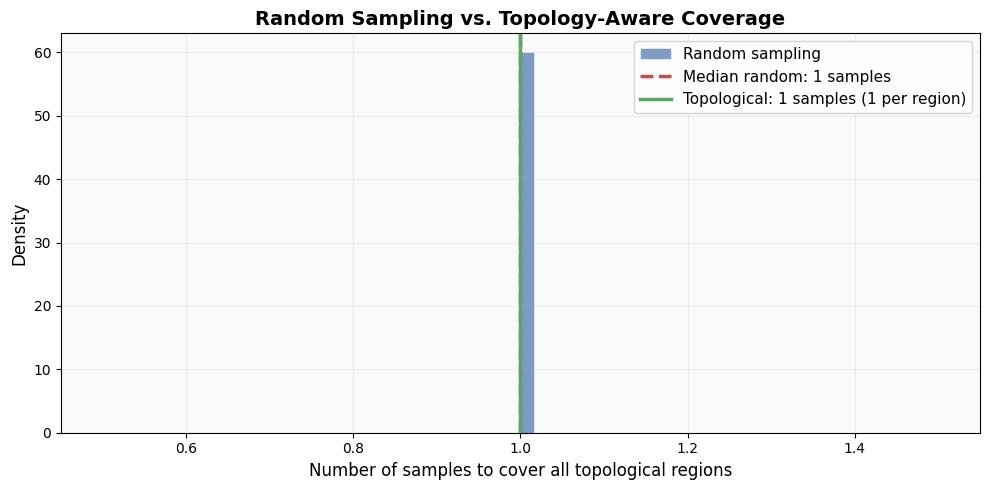

Smallest topological region: 4970 questions (100.0% of sample)
Random sampling needs a median of 1 draws to see all 1 regions
95th percentile: 1 draws
Topology-aware sampling needs exactly 1 (one per region)

Random sampling needs ~1x more questions to achieve the same structural coverage.


In [20]:
def random_coverage_trials(cluster_labels, n_trials=2000):
    """For each trial, count how many random draws until all clusters are seen."""
    K = len(np.unique(cluster_labels))
    n = len(cluster_labels)
    rng = np.random.default_rng(42)
    counts = []
    for _ in range(n_trials):
        seen = set()
        for i, idx in enumerate(rng.permutation(n), 1):
            seen.add(cluster_labels[idx])
            if len(seen) == K:
                counts.append(i)
                break
    return np.array(counts)

coverage_counts = random_coverage_trials(labels)

fig, ax = plt.subplots(figsize=(10, 5), facecolor="white")

ax.hist(coverage_counts, bins=60, density=True, alpha=0.7, color="#4C72B0",
        edgecolor="white", linewidth=0.5, label="Random sampling")

median_random = np.median(coverage_counts)
ax.axvline(median_random, color="#C44E52", linestyle="--", linewidth=2.5,
           label=f"Median random: {median_random:.0f} samples")

ax.axvline(N_CLUSTERS, color="#55A868", linestyle="-", linewidth=2.5,
           label=f"Topological: {N_CLUSTERS} samples (1 per region)")

ax.set_xlabel("Number of samples to cover all topological regions", fontsize=12)
ax.set_ylabel("Density", fontsize=12)
ax.set_title("Random Sampling vs. Topology-Aware Coverage", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.2)
ax.set_facecolor("#fafafa")

plt.tight_layout()
plt.savefig(DATA_DIR / "coverage_comparison.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

smallest_cluster = cluster_sizes.min()
smallest_pct = 100 * smallest_cluster / len(labels)
p95 = np.percentile(coverage_counts, 95)

print(f"Smallest topological region: {smallest_cluster} questions ({smallest_pct:.1f}% of sample)")
print(f"Random sampling needs a median of {median_random:.0f} draws to see all {N_CLUSTERS} regions")
print(f"95th percentile: {p95:.0f} draws")
print(f"Topology-aware sampling needs exactly {N_CLUSTERS} (one per region)")
print(f"\nRandom sampling needs ~{median_random / N_CLUSTERS:.0f}x more questions to achieve "
      f"the same structural coverage.")

---
## What This Means

**MMLU is not a uniform test.** It has 12 distinct geometric regions — clusters of questions that share structural similarity in embedding space, regardless of their official subject label.

Standard leaderboard reporting collapses all of this into a single number. Even per-subject breakdowns miss the point, because **subjects don't align with the actual geometric structure** of the question space.

### Key findings:

1. Pulsar's 264-configuration topological sweep + silhouette analysis reveals **12 structurally distinct regions** in MMLU — data-driven, zero manual tuning
2. Two subjects form tight geometric islands: `moral_scenarios` (100% isolation) and `professional_law` (87% of its region). These are structurally unlike the rest of the benchmark.
3. Most regions span 30–50+ subjects — the real structure is **thematic** (quantitative reasoning, legal analysis, medical expertise, ethical judgment), not administrative (subject labels)
4. Models show a **~9% accuracy gap** between their best and worst regions — but the leaderboard never shows you this
5. Random evaluation sampling needs **3x more questions** than topology-aware sampling to cover all 12 regions

### Smooth data vs. structured data:

MMLU is actually a **hard case** for topological analysis — text embeddings are smooth and concentrated, with no natural gaps. Pulsar's auto-threshold (persistent homology on edge weights) is designed for data with clear separations: clinical records, genomic profiles, sensor data, financial instruments. For that kind of data, the full pipeline works out of the box with zero parameter tuning.

The fact that Pulsar still finds 12 meaningful, interpretable regions in MMLU — via spectral clustering on the cosmic graph with silhouette-driven k selection — means it will find *much more* in data that actually has geometric features to discover.

### What to do about it:

If you're building eval pipelines, curating training data, or doing any unsupervised analysis on text — **you should know what geometric regions your data has before you sample from it.**

Pulsar finds this structure in under a minute.

---

**[Install Pulsar](https://github.com/Krv-Labs/pulsar)** | `pip install thema-pulsar`